In [35]:
#SMART CAMPUS ANALYTICS SYSTEM 

In [36]:
# Firstly We Will convert the Raw data into The Smart Dataset......

In [37]:
#Loading the dataset and checking the dataset

import pandas as pd

df=pd.read_csv("campus.csv")

print(df.head())
print(df.info())

print(df.isnull().sum())

   Student_ID        Date Department Attendance  Hours_Spent  \
0         101  2026-01-04         CS    Present          3.0   
1         102  2026-02-04         CS    Present          0.0   
2         103  2026-03-04         CS    Present          7.0   
3         104  2026-04-04       AIML     Absent          0.0   
4         105  2026-05-04         IT    Present          5.0   

   Energy_Usage_kWh  Library_Visits  Lab_Usage_Hours  
0         11.000000               0                1  
1         13.000000               0                0  
2         10.289474               0                3  
3         12.000000               1                1  
4         12.000000               2                2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        50 non-null     int64  
 1   Date              50 non-null     obj

In [38]:
#Conversion of some columns for our betterment of model..

df['Date']=pd.to_datetime(df['Date'])

df['Attendance']=df['Attendance'].map({
    'Present':1,
    'Absent':0
})

In [39]:
#WE will add some meaningful Columns to get the Expected Output ...

df['Productivity_Score']=(
    df['Hours_Spent']* 0.4 +
    df['Library_Visits']* 0.3 +
    df['Lab_Usage_Hours'] * 0.3
)


def productivity_label(score):
    if score>6:
        return "High"
    elif score>3:
        return "Medium"
    else:
        return "Low"
df["Productivity_Level"]=df['Productivity_Score'].apply(productivity_label)


df['Energy_Efficiency']=df['Energy_Usage_kWh'] / ( df['Hours_Spent'] + df['Lab_Usage_Hours'] + 1
                                                 )                                                  


In [40]:
#Modified Dataset Ready...

print(df.head())
print(df.columns)

   Student_ID       Date Department  Attendance  Hours_Spent  \
0         101 2026-01-04         CS           1          3.0   
1         102 2026-02-04         CS           1          0.0   
2         103 2026-03-04         CS           1          7.0   
3         104 2026-04-04       AIML           0          0.0   
4         105 2026-05-04         IT           1          5.0   

   Energy_Usage_kWh  Library_Visits  Lab_Usage_Hours  Productivity_Score  \
0         11.000000               0                1                 1.5   
1         13.000000               0                0                 0.0   
2         10.289474               0                3                 3.7   
3         12.000000               1                1                 0.6   
4         12.000000               2                2                 3.2   

  Productivity_Level  Energy_Efficiency  
0                Low           2.200000  
1                Low          13.000000  
2             Medium           0

In [41]:
# Stage 2 : EDA And Visualization

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

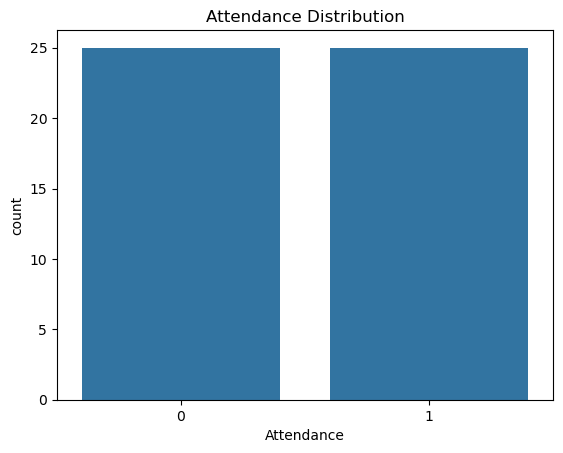

In [43]:
# Attendance Distribution

sns.countplot(x='Attendance',data=df)
plt.title("Attendance Distribution")
plt.show()

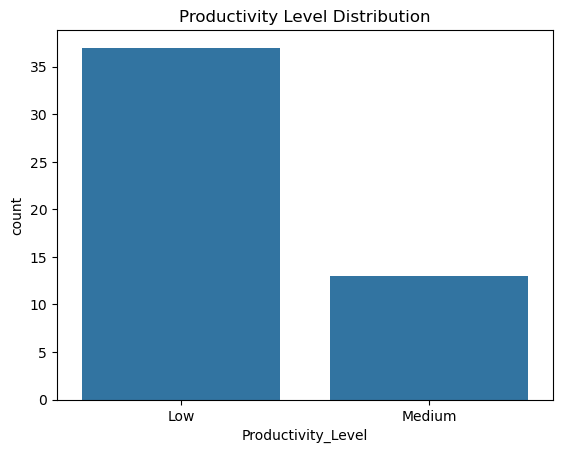

In [44]:
# Productivity Level Distribution

sns.countplot(x='Productivity_Level',data=df)
plt.title("Productivity Level Distribution")
plt.show()

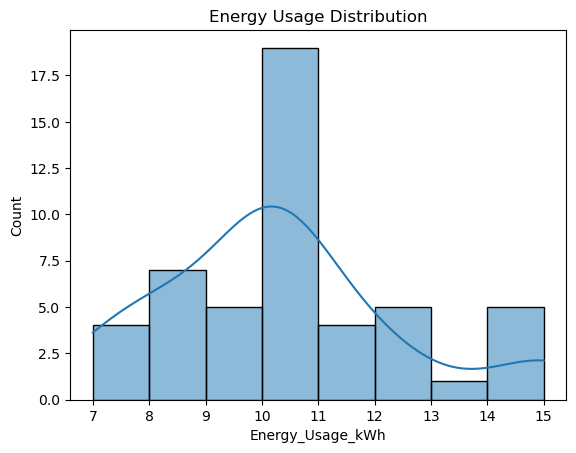

In [45]:
#Energy Usage Distribution

sns.histplot(df['Energy_Usage_kWh'],kde=True)
plt.title("Energy Usage Distribution")
plt.show()

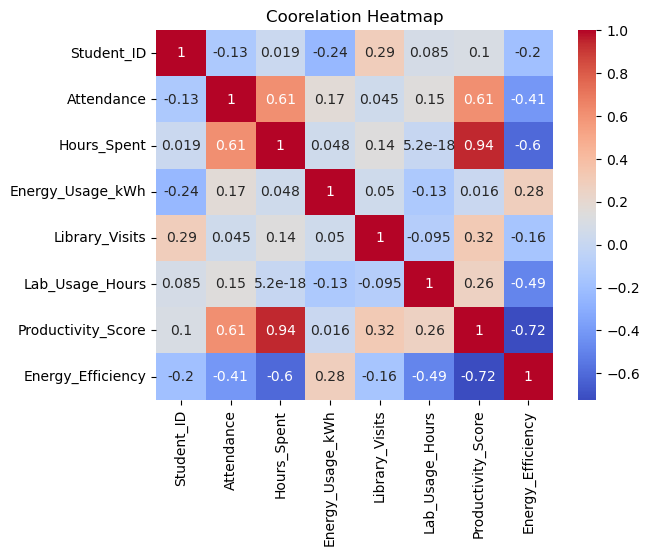

In [46]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Coorelation Heatmap")
plt.show()

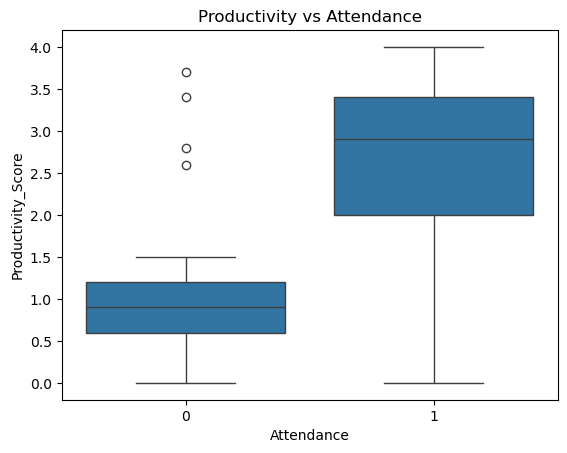

In [47]:
# Productivity V/s Attendance   ( OUTPUT 1)

sns.boxplot(x='Attendance',y='Productivity_Score',data=df)
plt.title("Productivity vs Attendance")
plt.show()

In [48]:
# STAGE 3 : MODEL DEVELOPMENT

In [49]:
# AS ML needs numeric value so we are transforming text values into Numeric Values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Productivity_Level_Encoded'] = le.fit_transform(df['Productivity_Level'])

In [50]:
# Declaring the Variables and importing the library

X= df[['Hours_Spent' , 'Library_Visits' , 'Lab_Usage_Hours' , 'Energy_Usage_kWh']]
y=df['Productivity_Level_Encoded']


from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X,y, test_size=0.2, random_state = 42
)

In [51]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [52]:
#Model Evaluation  ( OUTPUT:2)

from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [53]:
# Isolation Forest : Used For Small datasets where we dont tell what is normal or abnormal
#it will figure out by itself indirectly called Unsupervised Learning..

# This Algorithm Specifiaclly used for the Anamoly Detetection

features = df[['Hours_Spent','Library_Visits','Lab_Usage_Hours','Energy_Usage_kWh']]

from sklearn.ensemble import IsolationForest

iso_model=IsolationForest(contamination=0.1, random_state=42)

iso_model.fit(features)

df['Anomaly'] = iso_model.predict(features)

df['Anomaly_Label'] = df['Anomaly'].map({
    -1 : 'Anomaly',
    1 : 'Normal'
})

In [54]:
print(df[['Hours_Spent', 'Energy_Usage_kWh', 'Anomaly_Label']].head(10))   #OUTPUT 3

   Hours_Spent  Energy_Usage_kWh Anomaly_Label
0          3.0         11.000000        Normal
1          0.0         13.000000        Normal
2          7.0         10.289474        Normal
3          0.0         12.000000        Normal
4          5.0         12.000000        Normal
5          7.0         10.289474        Normal
6          0.0          8.000000        Normal
7          0.0         10.289474        Normal
8          7.0         10.000000        Normal
9          5.0         10.289474        Normal


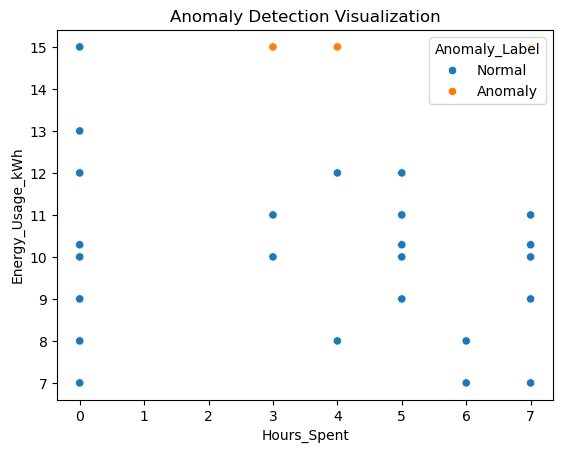

In [55]:
# For Better Visualization

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x='Hours_Spent',
    y='Energy_Usage_kWh',
    hue='Anomaly_Label',
    data=df
)

plt.title("Anomaly Detection Visualization")
plt.show()

In [ ]:
# User Input Prediction

hours = float(input("Enter Hours Spent: "))
library = int(input("Enter Library Visits: "))
lab = int(input("Enter Lab Usage Hours: "))
energy = float(input("Enter Energy Usage (kWh): "))


In [ ]:
#converting the input into model format

import numpy as np

user_data = np.array([[hours, library, lab, energy]])

prediction = model.predict(user_data)

predicted_label = le.inverse_transform(prediction)

print("Predicted Productivity:", predicted_label[0])

efficiency = energy / (hours + lab + 1)

print("Energy Efficiency:", efficiency)

anomaly = iso_model.predict(user_data)

if anomaly[0] == -1:
    print("Anomaly Detected")
else:
    print("Normal Behavior")